<h1>Can we predict what songs will be added to a playlist based on a user's listening behavior and the listening behavior of others?</h1>
<p>We can say that if a user added a song to a playlist, they “like” that song. Some users share similar tastes in music, so we can recommend music to one person based on the liked music of others. This can be accomplished using Implicit Alternating Least Squares.</p>

In [1]:
# Install required packages if not available
import sys
!{sys.executable} -m pip install kagglehub pandas numpy matplotlib seaborn plotly

print("Packages installed successfully!")

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

# Recommendation system libraries
from scipy.sparse import csr_matrix

# Install implicit if not available
import subprocess
import sys

print("Checking for implicit library...")
try:
    import implicit
    print(" implicit library is already available")
except ImportError:
    print(" implicit library not found. Installing...")
    try:
        # Try installing with pip
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'implicit'])
        print(" implicit library installed via pip")
        
        # Try importing again
        import implicit
        print(" implicit library imported successfully")
        
    except Exception as e:
        print(f" Installation failed: {e}")
        print(" Please try manually installing with: pip install implicit")
        print(" Or try: conda install -c conda-forge implicit")
        raise ImportError("Could not install implicit library")


Packages installed successfully!
Libraries imported successfully!
Checking for implicit library...
 implicit library is already available


In [2]:
# Load existing train/validation split files 
def load_existing_split(output_dir='./data_splits/'):
    """
    Load previously created train/validation split files
    Use this instead of recreating the split to save time
    """
    import os
    
    train_file = os.path.join(output_dir, 'train_data.csv')
    val_file = os.path.join(output_dir, 'validation_data.csv')
    
    print(" Loading existing train/validation split files...")
    
    # Check if files exist
    if not os.path.exists(train_file):
        print(f" Train file not found: {train_file}")
        print(" You need to run the split creation cell first!")
        return None, None
    
    if not os.path.exists(val_file):
        print(f" Validation file not found: {val_file}")
        print(" You need to run the split creation cell first!")
        return None, None
    
    # Load the files
    print(f" Loading train data from: {train_file}")
    df_train = pd.read_csv(train_file)
    
    print(f" Loading validation data from: {val_file}")
    df_validation = pd.read_csv(val_file)
    
    # Display info about loaded data
    print(f"\n Successfully loaded existing split:")
    print(f"   Train set: {len(df_train):,} interactions from {df_train['user_id'].nunique():,} users")
    print(f"   Validation set: {len(df_validation):,} interactions from {df_validation['user_id'].nunique():,} users")
    print(f"   Train tracks: {df_train['trackname'].nunique():,} unique tracks")
    print(f"   Validation tracks: {df_validation['trackname'].nunique():,} unique tracks")
    
    # Check data integrity
    common_users = set(df_train['user_id'].unique()).intersection(set(df_validation['user_id'].unique()))
    print(f"   Users in both sets: {len(common_users):,} (this is normal)")
    
    return df_train, df_validation

#  Load existing split 
print(" LOADING EXISTING TRAIN/VALIDATION SPLIT")
print("="*50)

df_train, df_validation = load_existing_split()
df = pd.concat([df_train,df_validation])

if df_train is not None and df_validation is not None:
    print(f"\n Ready to proceed with model training and validation!")
    print(f" No need to recreate the split - using existing files for speed")
else:
    print(f"\n  Could not load existing split files")
    print(f" Run the 'Create train/validation split' cell first to generate the files")

 LOADING EXISTING TRAIN/VALIDATION SPLIT
 Loading existing train/validation split files...
 Loading train data from: ./data_splits/train_data.csv
 Loading validation data from: ./data_splits/validation_data.csv

 Successfully loaded existing split:
   Train set: 10,226,828 interactions from 15,910 users
   Validation set: 2,247,978 interactions from 15,518 users
   Train tracks: 2,250,904 unique tracks
   Validation tracks: 665,365 unique tracks
   Users in both sets: 15,518 (this is normal)

 Ready to proceed with model training and validation!
 No need to recreate the split - using existing files for speed


<h1>Visualize the data </h1>
<p> First we need to visualize the data to understand the relationships between the users and the songs. In particular we need to visualize the disturibution of the number of songs added to playlists by users as well as the number of users who added each song to their playlists. </p>

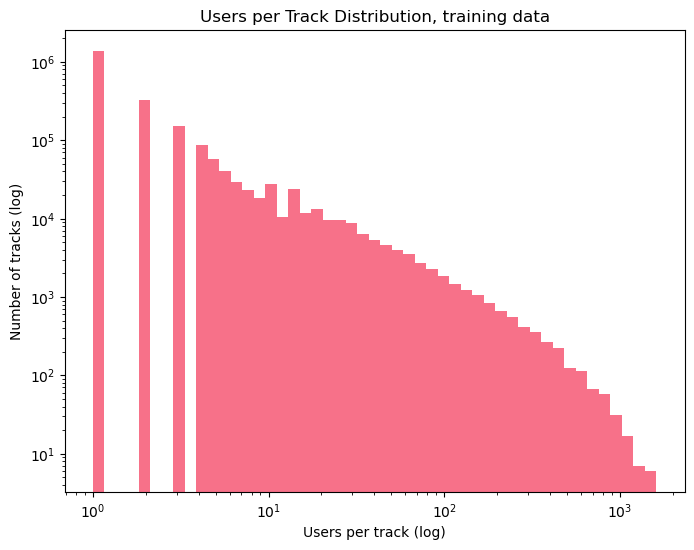

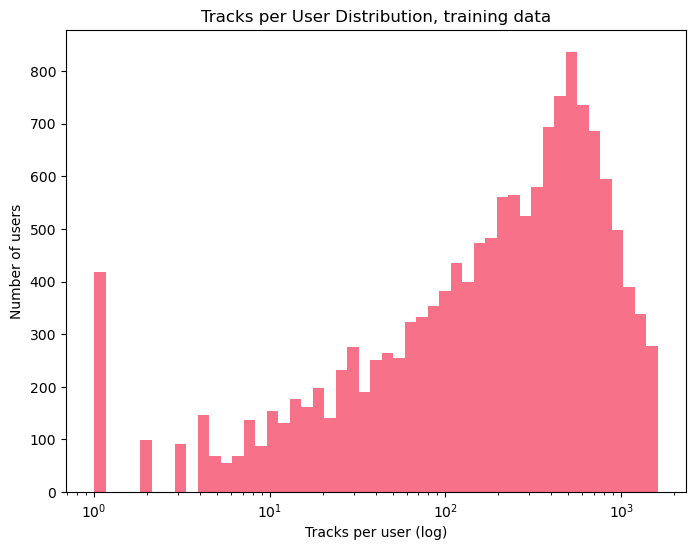

In [3]:
# users_per_track

users_per_track = (
    df_train.groupby("trackname")["user_id"]
      .nunique()
      .values
)

users_per_track = np.array(users_per_track)

bins = np.logspace(
    np.log10(users_per_track.min()),
    np.log10(users_per_track.max()),
    50
)

plt.figure(figsize=(8, 6))
plt.hist(users_per_track, bins=bins)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Users per track (log)')
plt.ylabel('Number of tracks (log)')
plt.title('Users per Track Distribution, training data')
plt.show()

# tracks_per_user
tracks_per_user = (
    df_train.groupby("user_id")["trackname"]
      .nunique()
      .values
)

plt.figure(figsize=(8, 6))
plt.hist(tracks_per_user, bins=bins)
plt.xscale("log")
plt.xlabel("Tracks per user (log)")
plt.ylabel("Number of users")
plt.title("Tracks per User Distribution, training data")
plt.show()

<h1>Preprocessing</h1>
<p> To prepare the data first it is necessary to clean the artist names and song names for uniformity (it needs to be clear that “Twelve Days of Christmas” is the same as “12 Days of Christmas”), and also concatenate the artist name with the song title (because different songs can have the same name). We also need to remove songs and users with too few interactions (in this case < 5 interactions), because this could potentially impede the model as “noise”. For validation, it is necessary to remove 20% of interactions per user and set them aside for testing. On the remaining 80% training data, we applied log scaling because we found the model performed better when we gave less influence to instances where a user added the same song to 2,3 or 4 playlists. We also applied BM25 weighting to dampen extreme play counts and reward rare song selections. The final prepared training data is a user-item interaction matrix, weighted and scaled without the playlist names or the artist names. </p>

In [4]:
# Filter out users and items with insufficient interactions. 

def filter_low_signal(df, min_tracks=5, min_users=5):
    """
    Applied to the FULL dataset to ensure every user/item in the 
    validation set also exists in the training set with sufficient signal.
    """
    print(f"Starting total records: {len(df):,}")
    
    # Iterative filtering to ensure both conditions are met
    while True:
        starting_size = len(df)
        df = df.groupby('trackname').filter(lambda x: len(x) >= min_users)
        df = df.groupby('user_id').filter(lambda x: len(x) >= min_tracks)
        if len(df) == starting_size:
            break
            
    print(f"Filtered total records: {len(df):,}")
    return df

df_train = filter_low_signal(df_train, min_tracks=5, min_users=5)
df_validation = filter_low_signal(df_validation, min_tracks=5, min_users=5)    

Starting total records: 10,226,828
Filtered total records: 7,309,402
Starting total records: 2,247,978
Filtered total records: 1,334,980


In [5]:
from implicit.nearest_neighbours import bm25_weight

def build_training_matrix(df_train):
    """
    Creates the weighted matrix for the ALS model to learn from.
    """
    # 1. Aggregate and Log Scale
    counts = df_train.groupby(['user_id', 'trackname']).size().reset_index(name='c')
    counts['w'] = np.log1p(counts['c'])
    
    # 2. Map to Categorical (Crucial for matrix indexing)
    counts['user_id'] = counts['user_id'].astype('category')
    counts['trackname'] = counts['trackname'].astype('category')
    
    # 3. Create Sparse Matrix
    train_matrix = csr_matrix(
        (counts['w'].astype(np.float32), 
        (counts['user_id'].cat.codes, counts['trackname'].cat.codes))
    )
    
    # 4. Apply BM25 Weighting
    # This happens ONLY on training data
    weighted_train = bm25_weight(train_matrix, K1=1.2, B=0.75).tocsr()
    
    # Keep these to align the validation set later
    user_categories = counts['user_id'].cat.categories
    track_categories = counts['trackname'].cat.categories
    
    return weighted_train, user_categories, track_categories

train_processed, u_cat, t_cat = build_training_matrix(df_train)
print("Training matrix built successfully!")


Training matrix built successfully!


<h1> Visualize the data after preprocessing </h1>

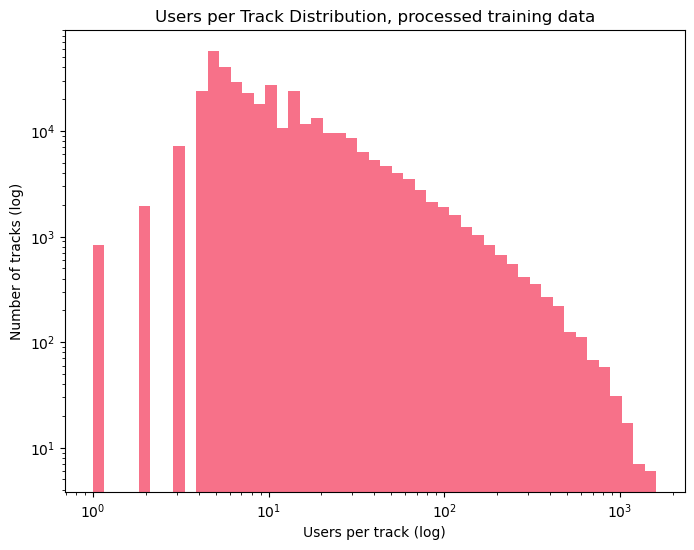

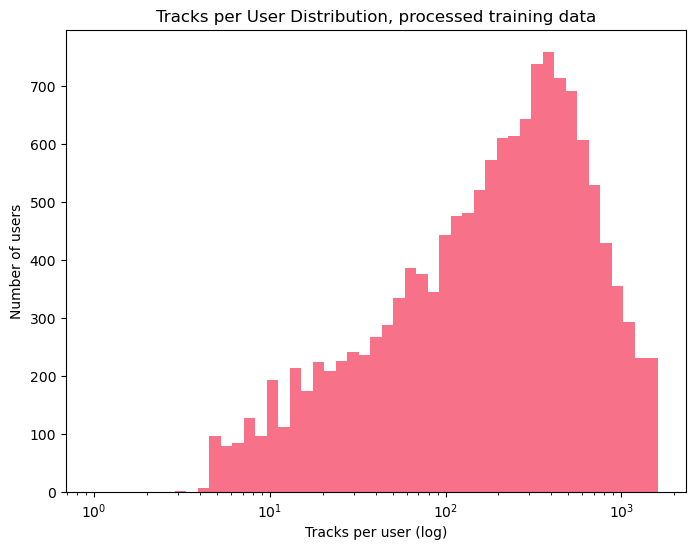

In [6]:
def sparse_matrix_to_df(sparse_matrix, u_cat, t_cat):
    """
    Converts a CSR matrix back to a readable DataFrame using category mappings.
    """
    row, col = sparse_matrix.nonzero()
    data = sparse_matrix.data
    df_preview = pd.DataFrame({
        'user_id': u_cat[row],
        'trackname': t_cat[col],
        'weight': data
    })
    return df_preview

df_processed = sparse_matrix_to_df(train_processed, u_cat, t_cat)

# users_per_track

users_per_track = (
    df_processed.groupby("trackname")["user_id"]
      .nunique()
      .values
)

users_per_track = np.array(users_per_track)

bins = np.logspace(
    np.log10(users_per_track.min()),
    np.log10(users_per_track.max()),
    50
)

plt.figure(figsize=(8, 6))
plt.hist(users_per_track, bins=bins)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Users per track (log)')
plt.ylabel('Number of tracks (log)')
plt.title('Users per Track Distribution, processed training data')
plt.show()

# tracks_per_user
tracks_per_user = (
    df_processed.groupby("user_id")["trackname"]
      .nunique()
      .values
)

plt.figure(figsize=(8, 6))
plt.hist(tracks_per_user, bins=bins)
plt.xscale("log")
plt.xlabel("Tracks per user (log)")
plt.ylabel("Number of users")
plt.title("Tracks per User Distribution, processed training data")
plt.show()

In [7]:
def build_validation_matrix(df_val, user_categories, track_categories):
    """
    Creates a binary/raw matrix for validation. 
    Matches IDs to the training matrix.
    """
    # Map validation IDs to the training category codes
    # Any item in Val NOT in Train will be dropped (NaN)
    user_map = {name: i for i, name in enumerate(user_categories)}
    track_map = {name: i for i, name in enumerate(track_categories)}
    
    df_val['u_idx'] = df_val['user_id'].map(user_map)
    df_val['t_idx'] = df_val['trackname'].map(track_map)
    
    # Drop records that couldn't be mapped (if any)
    df_val = df_val.dropna(subset=['u_idx', 't_idx'])
    
    val_matrix = csr_matrix(
        (np.ones(len(df_val), dtype=np.float32), 
        (df_val['u_idx'].astype(int), df_val['t_idx'].astype(int))),
        shape=(len(user_categories), len(track_categories))
    )
    
    return val_matrix

validation = build_validation_matrix(df_validation, u_cat, t_cat)
print("Validation matrix built successfully!")

Validation matrix built successfully!


<h1>Build the Model</h1>
<p> Implicit Alternating Least Squares maps each song and user in multidimensional space and alternates between keeping the user vectors fixed while solving for the song vectors, and keeping the song vectors fixed while solving for the user vectors, for a specified number of iterations, at which point the model should converge to a point of low error. </p>

In [8]:
import random
from implicit.evaluation import AUC_at_k

# Initialize the ALS model
model = implicit.als.AlternatingLeastSquares(
    factors=50, 
    regularization=0.1, 
    iterations=15,
    random_state=42
)

print(f"Training matrix shape: {train_processed.shape} (users x items)")

model.fit(train_processed) 

print(f" Model trained successfully!")
print(f"Model user factors: {model.user_factors.shape[0]} users")
print(f"Model item factors: {model.item_factors.shape[0]} items")

Training matrix shape: (14878, 354258) (users x items)


c:\Users\mstan\anaconda3\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 6 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

 Model trained successfully!
Model user factors: 14878 users
Model item factors: 354258 items


<h1>Initial Model Evaluation</h1>
<p> For this context we focus on Roc AUC at K and MPR (mean percentile rank). A low MPR tells us that the held-out songs were ranked relatively highly by the model for those user-song pairs. And an AUC significantly higher than .5 tells us that there is a greater than 50% chance the user will like our recommendations more than random song choices. 
</p>

In [9]:
import tqdm

def evaluate_recommender(model, train_matrix, validation_matrix, n_users=500):
    user_factors = model.user_factors
    item_factors = model.item_factors
    n_items = item_factors.shape[0]
    
    val_user_indices = np.where(np.diff(validation_matrix.indptr) > 0)[0]
    sample_users = np.random.choice(val_user_indices, size=min(n_users, len(val_user_indices)), replace=False)

    auc_scores = []
    percentile_ranks = []

    for user_id in tqdm.tqdm(sample_users, desc="Model Evaluation"):
        # 1. Get items from TRAINING (to hide them) and VALIDATION (to test them)
        train_start, train_end = train_matrix.indptr[user_id], train_matrix.indptr[user_id+1]
        train_items = train_matrix.indices[train_start:train_end]
        
        val_start, val_end = validation_matrix.indptr[user_id], validation_matrix.indptr[user_id+1]
        val_items = validation_matrix.indices[val_start:val_end]
        
        # 2. Get Scores
        user_vector = user_factors[user_id]
        all_scores = user_vector.dot(item_factors.T)
        
        # 3. THE FIX: Set scores of training items to -infinity so they don't rank at the top
        all_scores[train_items] = -np.inf
        
        for item_id in val_items:
            # Rank amongst non-training items
            rank = np.sum(all_scores > all_scores[item_id])
            percentile_ranks.append(rank / (n_items - len(train_items)))
            
            # AUC against a random item the user hasn't seen
            neg_item_id = np.random.randint(0, n_items)
            while neg_item_id in train_items or neg_item_id in val_items:
                neg_item_id = np.random.randint(0, n_items)
                
            if all_scores[item_id] > all_scores[neg_item_id]:
                auc_scores.append(1)
            else:
                auc_scores.append(0)

    return np.mean(auc_scores), np.mean(percentile_ranks)


print("\n" + "="*40)
print(" RUNNING EVALUATION")
print("="*40)

try:
    auc, mpr = evaluate_recommender(model, train_processed, validation)
    
    print("\n" + " FINAL METRICS")
    print("-" * 20)
    print(f"AUC Score: {auc:.4f}")
    print(f"MPR Score: {mpr:.4f}")
    print("-" * 20)
    
    # Summary Analysis
    if auc < 0.6 and mpr < 0.01:
        print("\n ANALYSIS: The model is likely suffering from 'Popularity Bias'.")
        print("Model is very good at ranking hits (low MPR), but struggles to distinguish")
        print("between personalized niche tracks (low AUC).")
    elif auc > 0.7:
        print("\n ANALYSIS: The model has strong personalization!")
        
except Exception as e:
    print(f"Error during evaluation: {e}")


 RUNNING EVALUATION


Model Evaluation: 100%|██████████| 500/500 [00:15<00:00, 32.95it/s]


 FINAL METRICS
--------------------
AUC Score: 0.7338
MPR Score: 0.2679
--------------------

 ANALYSIS: The model has strong personalization!


<h1>Retrain the model after hyperparameter tuning</h1>
<p> Our best performing configuration had BM25 values of K1 (saturation) = 1.2 and B (normalization) = .75. The saturation controls the dropoff of how much we should consider a user adding a song 2 times vs 3 times vs 4. The normalization controls how much we should account for highly active users. 100 iterations was found to perform well and regularization of 0.1 was used to account for overfitting. </p>

In [10]:
# Initialize the ALS model
model = implicit.als.AlternatingLeastSquares(
    factors=100, 
    regularization=0.1, 
    iterations=20,
    random_state=42
)

print(f"Training matrix shape: {train_processed.shape} (users x items)")

model.fit(train_processed) 

print(f" Model trained successfully!")
print(f"Model user factors: {model.user_factors.shape[0]} users")
print(f"Model item factors: {model.item_factors.shape[0]} items")

Training matrix shape: (14878, 354258) (users x items)


  0%|          | 0/20 [00:00<?, ?it/s]

 Model trained successfully!
Model user factors: 14878 users
Model item factors: 354258 items


<h1>Evaluation of the tuned model</h1>
<p> Our tuned model scored an MPR of < 24% and AUC of 60% indicating that while there is room for improvement, the model is clearly recommending songs that are more relevant to the user than if we were to recommend songs randomly. The 60% AUC is based on the Global AUC*. Using Single-Point Stochastic (Random) Negative sampling, we are seeing an AUC score of 76%</p>

In [11]:
try:
    auc, mpr = evaluate_recommender(model, train_processed, validation)
    
    print("\n" + " FINAL METRICS")
    print("-" * 20)
    print(f"AUC Score with Stochastic Negative Sampling): {auc:.4f}")
    print(f"MPR Score: {mpr:.4f}")
    print("-" * 20)
    
    # Summary Analysis
    if auc < 0.6 and mpr < 0.01:
        print("\n ANALYSIS: The model is likely suffering from 'Popularity Bias'.")
        print("Model is very good at ranking hits (low MPR), but struggles to distinguish")
        print("between personalized niche tracks (low AUC).")
    elif auc > 0.7:
        print("\n ANALYSIS: The model has strong personalization!")
        
except Exception as e:
    print(f"Error during evaluation: {e}")

Model Evaluation: 100%|██████████| 500/500 [00:16<00:00, 30.30it/s]


 FINAL METRICS
--------------------
AUC Score with Stochastic Negative Sampling): 0.7817
MPR Score: 0.2179
--------------------

 ANALYSIS: The model has strong personalization!


<h1> Train model on full dataset </h1>
<p> After hyperparameter tuning and evaluation, we can retrain the model on the full dataset (without holding out 20% of interactions for validation). This will allow the model to learn from all available data and potentially improve its recommendation performance. </p>

In [12]:
df_filtered = filter_low_signal(df, min_tracks=5, min_users=5)
df_matrix, u_cat, t_cat = build_training_matrix(df_filtered)
model = implicit.als.AlternatingLeastSquares(
    factors=100, 
    regularization=0.1, 
    iterations=20,
    random_state=42
)

print(f"Training matrix shape: {df_matrix.shape} (users x items)")

model.fit(df_matrix) 

print(f" Model trained successfully!")
print(f"Model user factors: {model.user_factors.shape[0]} users")
print(f"Model item factors: {model.item_factors.shape[0]} items")

Starting total records: 12,474,806
Filtered total records: 9,488,707
Training matrix shape: (15051, 431334) (users x items)


  0%|          | 0/20 [00:00<?, ?it/s]

 Model trained successfully!
Model user factors: 15051 users
Model item factors: 431334 items


<h1>Final Model Summary</h1>

In [13]:
def global_recommendation_summary(model, train_matrix, track_map, n_users=1000):
    from collections import Counter
    
    print(f"Sampling {n_users} users to find global trends...")
    global_counts = Counter()
    
    # Sample users
    user_indices = np.random.choice(train_matrix.shape[0], size=n_users, replace=False)
    
    for user_id in user_indices:
        ids, _ = model.recommend(user_id, train_matrix[user_id], N=10)
        global_counts.update(ids)
    
    print("\n--- The 10 Most Recommended Songs Globally ---")
    for i, (track_id, count) in enumerate(global_counts.most_common(10)):
        print(f"{i+1}. {track_map[track_id]} (Recommended to {count/n_users:.1%} of sample)")

global_recommendation_summary(model, df_matrix, t_cat)

Sampling 1000 users to find global trends...

--- The 10 Most Recommended Songs Globally ---
1. passenger - let her go (Recommended to 3.5% of sample)
2. m83 - midnight city (Recommended to 3.4% of sample)
3. imagine dragons - radioactive (Recommended to 3.4% of sample)
4. avicii - wake me up (Recommended to 3.2% of sample)
5. of monsters and men - little talks (Recommended to 3.1% of sample)
6. hozier - take me to church (Recommended to 3.1% of sample)
7. macklemore and ryan lewis - cant hold us - feat. ray dalton (Recommended to 3.1% of sample)
8. clean bandit - rather be (Recommended to 3.0% of sample)
9. calvin harris - summer (Recommended to 3.0% of sample)
10. the lumineers - ho hey (Recommended to 2.8% of sample)


<p>This model also allows us to extract reasoning for song recommendations. When we pick random song recommendations from the trained model and look at the similar songs in the user’s history that resulted in that recommendation we can see some clear examples of relevant and customized recommendations. In some cases we even see instances of a user having an affinity for a certain artist, and the model recommends songs by that artist, even though the artist names were not included in this model. </p>

In [14]:
def explain_random_recommendations(model, train_matrix, track_map, n_users=5):
    print(f"--- Explaining Recommendations for {n_users} Random Users ---")
    
    user_indices = np.random.choice(train_matrix.shape[0], size=n_users, replace=False)
    
    for user_id in user_indices:
        # 1. Get the top recommendation for this user
        ids, scores = model.recommend(user_id, train_matrix[user_id], N=1)
        if len(ids) == 0: continue
        
        rec_id = ids[0]
        rec_name = track_map[rec_id]
        
        # 2. Explain WHY that specific song was recommended
        total_score, top_contributions, _ = model.explain(user_id, train_matrix, itemid=rec_id)
        
        print(f"\nUser {user_id} Recommendation: '{rec_name}' (Total Score: {total_score:.3f})")
        print("Because you liked these songs in your history:")
        for track_idx, score in top_contributions[:3]: # Show top 3 contributors
            print(f"   - {track_map[track_idx]} (Contribution: {score:.3f})")
        print("-" * 30)

explain_random_recommendations(model, df_matrix, t_cat)

--- Explaining Recommendations for 5 Random Users ---

User 12635 Recommendation: 'imagine dragons - radioactive' (Total Score: 0.559)
Because you liked these songs in your history:
   - imagine dragons - its time (Contribution: 0.027)
   - onerepublic - counting stars (Contribution: 0.023)
   - the lumineers - ho hey (Contribution: 0.018)
------------------------------

User 3825 Recommendation: 'daft punk - instant crush' (Total Score: 0.245)
Because you liked these songs in your history:
   - ramin djawadi - pacific rim (Contribution: 0.007)
   - calle 13 - me vieron cruzar (Contribution: 0.006)
   - calle 13 - la vida (Contribution: 0.006)
------------------------------

User 5286 Recommendation: 'jason mraz - im yours' (Total Score: 0.132)
Because you liked these songs in your history:
   - the fray - you found me (Contribution: 0.014)
   - train - drops of jupiter (Contribution: 0.012)
   - alicia keys - empire state of mind broken down (Contribution: 0.010)
---------------------

<p><i>*Global AUC not shown here due to compatibility issues between the Implicit library and the Quarto environment. AUC is shown instead with single-point stochastic sampling.</o>